In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_tratado = pd.read_csv('/content/drive/MyDrive/P2_Estatística_grupo/Analise Exploratoria/absenteeism.csv' )

## Remoção de duplicatas

In [ ]:
quantidade_duplicadas = df_tratado.duplicated().sum()
print(f"Existem {quantidade_duplicadas} linhas duplicadas na base.")

Existem 34 linhas duplicadas na base.


In [ ]:
# O parâmetro inplace=True já aplica a limpeza direto na variável df
df_tratado.drop_duplicates(inplace=True)

## Tratamento do Mês de Absence igual a zero

### O que foi feito?

Utilizamos a moda da Season, assim evitamos imputar um dado fora da época certa, que carrega consigo informações como Clima e eventos esportivos ou escolares que poderiam ter refexo direto no motivo.

In [ ]:
# Criamos um mapeamento da moda de cada estação (excluindo os zeros)
mapa_modas = df_tratado[df_tratado['Month_of_absence'] > 0].groupby('Seasons')['Month_of_absence'].agg(lambda x: x.mode()[0])

# Aplicamos apenas onde o mês for 0
df_tratado.loc[df_tratado['Month_of_absence'] == 0, 'Month_of_absence'] = df_tratado['Seasons'].map(mapa_modas)

print("Imputação concluída!")

Imputação concluída!


In [ ]:
df_raw.describe()

,ID,Reason_for_absence,Month_of_absence,Day_of_the_week,Seasons,Transportation_expense,Distance_from_Residence_to_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_time_in_hours
count,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,...,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000
mean,18.192635,18.882436,6.430595,3.890935,2.549575,222.977337,29.297450,12.495751,36.478754,272089.984419,...,0.056657,1.291785,1.060907,0.565156,0.076487,0.769122,79.005666,172.202550,26.635977,7.143059
std,10.927472,8.482877,3.383544,1.425503,1.121527,67.293426,14.706661,4.370190,6.563404,39458.780251,...,0.231350,0.671499,1.104717,0.496088,0.265965,1.333351,12.862501,6.159814,4.254901,13.608120
min,1.000000,0.000000,1.000000,2.000000,1.000000,118.000000,5.000000,1.000000,27.000000,205917.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,56.000000,163.000000,19.000000,0.000000
25%,10.000000,13.000000,3.000000,3.000000,2.000000,179.000000,16.000000,9.000000,31.000000,244387.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,69.000000,169.000000,24.000000,2.000000
50%,18.000000,23.000000,6.000000,4.000000,3.000000,225.000000,26.000000,13.000000,37.000000,264604.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,80.000000,171.000000,25.000000,3.000000
75%,28.000000,26.000000,9.750000,5.000000,4.000000,260.000000,49.000000,16.000000,40.000000,294217.000000,...,0.000000,1.000000,2.000000,1.000000,0.000000,1.000000,89.000000,172.000000,31.000000,8.000000
max,36.000000,28.000000,12.000000,6.000000,4.000000,388.000000,52.000000,29.000000,58.000000,378884.000000,...,1.000000,4.000000,4.000000,1.000000,1.000000,8.000000,108.000000,196.000000,38.000000,120.000000


## Tratamento de registos com Zero Horas

- Existem 44 regristros com 0 horas, para não prejudicar os demais dados de análise, foi criada um novo df onde só aparecem as linhas em que o Absenteeism_time_in_hours > 0 . Assim, nós poderemos observar se a média estava sendo afetada pelos 0 que apareciam.

- Faremos também uma Winsorização com o df que não possui os zeros.

- Criamos uma nova coluna para os dados winsorizados para manter a rastrabilidade, o gráfico será plotado em cima dessa coluna

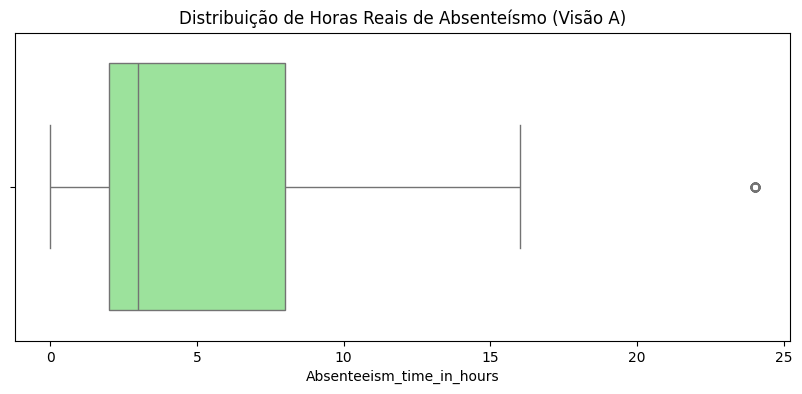

In [ ]:
df_tratado['Absenteeism_time_in_hours'] = winsorize(df_tratado['Absenteeism_time_in_hours'], limits=[0.05, 0.05])

# 4. Gera o Boxplot realista
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_tratado['Absenteeism_time_in_hours'], color='lightgreen')
plt.title('Distribuição de Horas Reais de Absenteísmo (Visão A)')
plt.show()

<Axes: >

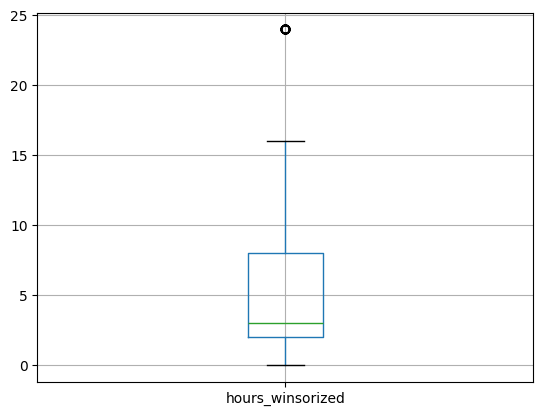

In [ ]:
from scipy.stats.mstats import winsorize

# Aplicando 5% em cada extremidade (total 10% de ajuste)
df_tratado['hours_winsorized'] = winsorize(df_tratado['Absenteeism_time_in_hours'], limits=[0.05, 0.05])

# Agora você pode gerar o boxplot dessa nova coluna
df_tratado.boxplot(column='hours_winsorized')


No caso da coluna *Reason_for_absence, a "melhor forma" de imputação não é usar uma média ou moda estatística, mas sim uma **atribuição lógica baseada em outra coluna*.

Como você descobriu que quase todos esses casos (40 de 44) coincidem com a coluna ⁠ Disciplinary_failure ⁠ sendo *1, o valor zero na verdade não é um dado ausente, mas sim um **código específico*.

### A Minha Sugestão: Não mude o valor, mude o rótulo

Na documentação original desse dataset (UCI), o código *0* é oficialmente reservado para casos de *"Unknown" (Desconhecido)* ou *"Disciplinary Failure"*. Portanto, imputar qualquer outro motivo (como "doença" ou "fisioterapia") seria criar uma informação falsa.

*O que fazer na prática:*
Em vez de tentar "adivinhar" o motivo, a melhor conduta é transformar esse "0" em uma categoria textual clara. Isso evita que você precise deletar as linhas e mantém a honestidade dos dado

In [ ]:
df_tratado['Reason_for_absence'] = df_tratado['Reason_for_absence'].astype(int).astype(str)
df_tratado.loc[df_tratado['Reason_for_absence'] == '0', 'Reason_for_absence'] = 'Punição Disciplinar'

print("Valores '0' na coluna 'Reason_for_absence' substituídos por 'Punição Disciplinar'.")

Valores '0' na coluna 'Reason_for_absence' substituídos por 'Punição Disciplinar'.


/tmp/ipykernel_7729/1632718436.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Reason_for_absence', data=df_tratado, order=df_tratado['Reason_for_absence'].value_counts().index, palette='viridis')


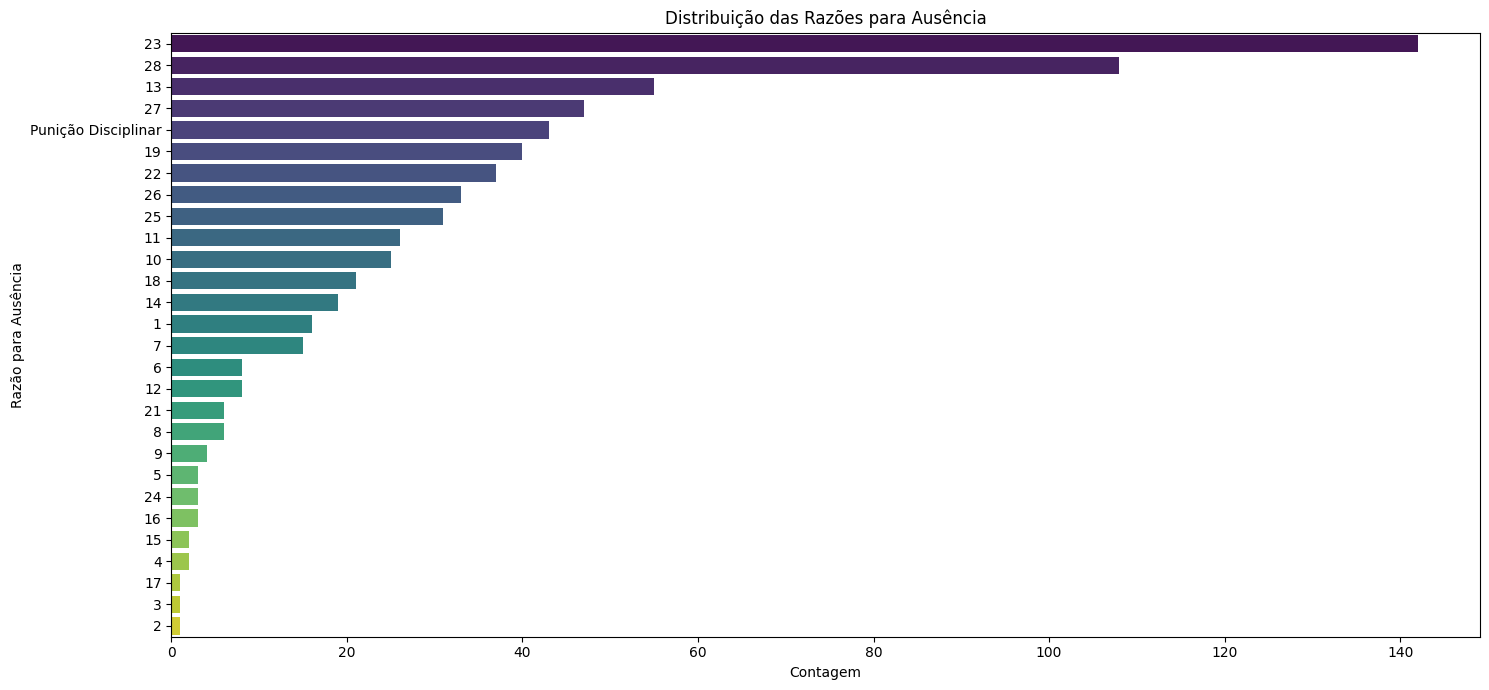

In [ ]:
plt.figure(figsize=(15, 7))
sns.countplot(y='Reason_for_absence', data=df_tratado, order=df_tratado['Reason_for_absence'].value_counts().index, palette='viridis')
plt.title('Distribuição das Razões para Ausência')
plt.xlabel('Contagem')
plt.ylabel('Razão para Ausência')
plt.tight_layout()
plt.show()

## Conversão de tipos de variáveis

- Quando você for gerar um gráfico com Month_of_absence, o Python não vai mais tentar colocar uma escala de $2.5, 5.0, 7.5...$ no eixo. Ele vai listar cada mês como um rótulo discreto.

- Estatísticas: O comando .describe() agora vai ignorar essas colunas se você rodar para números, ou te dar estatísticas de texto (como "Top" e "Frequência") se você rodar especificamente para elas.

- Limpeza visual: Ao converter para int antes de str, você remove aquele .0 (ex: de 11.0 vira apenas '11'), o que deixa seus painéis muito mais limpos e legíveis.

In [ ]:
# Lista das colunas que são, na verdade, categorias
colunas_categoricas = [
    'ID', 'Reason_for_absence', 'Month_of_absence',
    'Day_of_the_week', 'Seasons', 'Disciplinary_failure',
    'Education', 'Social_drinker', 'Social_smoker'
]

# Convertendo para string (object)
# Usamos o .astype(int) antes para remover o ".0" e depois para str
for col in colunas_categoricas:
    # Tenta converter a coluna para numérico. Valores não numéricos se tornam NaN.
    temp_series = pd.to_numeric(df_tratado[col], errors='coerce')

    # Se todos os valores foram convertidos com sucesso para numérico (sem NaNs),
    # então é seguro converter para int e depois para str para remover o ".0".
    if temp_series.notna().all():
        df_tratado[col] = df_tratado[col].astype(int).astype(str)
    else:
        # Caso contrário (contém strings não numéricas como 'Punição Disciplinar'),
        # converte diretamente para str.
        df_tratado[col] = df_tratado[col].astype(str)

# Verificando se a conversão funcionou
print(df_tratado[colunas_categoricas].dtypes)
print("\nExemplo dos dados convertidos:")
print(df_tratado[colunas_categoricas].head())

ID                      object
Reason_for_absence      object
Month_of_absence        object
Day_of_the_week         object
Seasons                 object
Disciplinary_failure    object
Education               object
Social_drinker          object
Social_smoker           object
dtype: object

Exemplo dos dados convertidos:
   ID   Reason_for_absence Month_of_absence Day_of_the_week Seasons  \
0  11                   26                7               3       1   
1  36  Punição Disciplinar                7               3       1   
2   3                   23                7               4       1   
3   7                    7                7               5       1   
4  11                   23                7               5       1   

  Disciplinary_failure Education Social_drinker Social_smoker  
0                    0         1              1             0  
1                    1         1              1             0  
2                    0         1              1         

## Padronização e Normalização

In [ ]:
df_tratado.head()

,ID,Reason_for_absence,Month_of_absence,Day_of_the_week,Seasons,Transportation_expense,Distance_from_Residence_to_Work,Service_time,Age,Work_load_Average_day,...,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_time_in_hours,hours_winsorized
0,11,26,7,3,1,289.0,36.0,13.0,33.0,239554.0,...,1,2.0,1,0,1.0,90.0,172.0,30.0,4.0,4.0
1,36,Punição Disciplinar,7,3,1,118.0,13.0,18.0,50.0,239554.0,...,1,1.0,1,0,0.0,98.0,178.0,31.0,0.0,0.0
2,3,23,7,4,1,179.0,51.0,18.0,38.0,239554.0,...,1,0.0,1,0,0.0,89.0,170.0,31.0,2.0,2.0
3,7,7,7,5,1,279.0,5.0,14.0,39.0,239554.0,...,1,2.0,1,1,0.0,68.0,168.0,24.0,4.0,4.0
4,11,23,7,5,1,289.0,36.0,13.0,33.0,239554.0,...,1,2.0,1,0,1.0,90.0,172.0,30.0,2.0,2.0


In [ ]:
df_tratado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 706 entries, 0 to 739
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               706 non-null    object 
 1   Reason_for_absence               706 non-null    object 
 2   Month_of_absence                 706 non-null    object 
 3   Day_of_the_week                  706 non-null    object 
 4   Seasons                          706 non-null    object 
 5   Transportation_expense           706 non-null    float64
 6   Distance_from_Residence_to_Work  706 non-null    float64
 7   Service_time                     706 non-null    float64
 8   Age                              706 non-null    float64
 9   Work_load_Average_day            706 non-null    float64
 10  Hit_target                       706 non-null    float64
 11  Disciplinary_failure             706 non-null    object 
 12  Education                  

## Salvar em CSV o dado tratado

In [ ]:
df_tratado.to_csv('/content/drive/My Drive/absenteeism_tratado.csv', index=False, encoding='utf-8-sig')